#  Bagging classifier

Bagging (Bootstrap Aggregating) is an ensemble learning technique that improves model accuracy and reduces overfitting by training multiple base models on different bootstrap samples of the dataset. Each sample is drawn randomly with replacement. 

In bagging classifier the final prediction is made by aggregating the predictions of all base model using majority voting. 

In the models of regression the final prediction is made by averaging the predictions of the all base model and that is known as bagging regression.

For each of the bootstrapped subsets, a separate classifier (e.g., decision tree, logistic regression) is trained.

Bagging helps improve accuracy and reduce overfitting especially in models that have high variance.

Bagging Classifier process begins with the original training dataset which is used to create bootstrap samples (random subsets with replacement) for training multiple weak learners ensuring diversity.

Each weak learner independently predicts outcomes. These predictions are aggregated using majority voting where the final classification is determined by the maximum voted output.
 
The Out-of-Bag (OOB) evaluates models performance on data excluded from each bootstrap sample for validation. This approach enhances accuracy and reduces overfitting.

# Python implementation of the Bagging classifier
Initialization: Stores the base classifier and number of estimators.

Training (fit method): Creates bootstrap samples, trains multiple classifiers, and stores them.

Prediction (predict method): Uses majority voting to combine predictions.


In [14]:
import numpy as np
from sklearn.base import clone
from collections import Counter

class Bagging_Classifier:
    def __init__(self, base_classifier, n_estimators = 10):
        """
        Initialize the bagging classifier.

        Parameters:
        - base_classifier: the base model to e used in bagging (e.g DecisoinTreeClassifier).
        - n_estimators: Number of base classifiers to train.
        """

        self.base_classfier = base_classifier # store the base model
        self.n_estimators = n_estimators # number of models in the ensemble
        self.classifiers = [] # List of store trained classifiers

    def fit(self, X, y):
        """
        Train the bagging classifier by creating multiple base classifiers.

        Parameters:
        - X: Feature matrix (numpy array or pandas DataFrame)
        - y: Target values (numpy array or pandas Series)  
        """
        self.classifiers = [] # Clear previously trained classifiers
        n_samples = len(X) # Number of samples in the dataset

        for _ in range(self.n_estimators):
            # Bootstrap sampling: Randomly n_samples indices with replacement
            indices = np.random.choice(n_samples,n_samples,replace=True)
            X_sampled, y_sampled = X[indices], y[indices] # create subset of data

            # Clone the  base classifier to ensure each model is independent
            clf = clone(self.base_classfier)
            clf.fit(X_sampled,y_sampled) # train on sampled data

            # Store the trained classifier
            self.classifiers.append(clf)

    def predict(self,X):
        """
        predict the class labels for input data using majority voting.

        Parameters:
        - X: Feature matrix for prediction.

        Returns:
        - final_predictions: The predicted class labels (numpy array). 
        """

        # collect predictions from all classifiers
        predictions = np.array([clf.predict(X) for clf in self.classifiers])
        """
        apply_along_axis - applies the function column-wise (axis=0), meaning it processes one sample at a time.

        The function receives an array x (which contains predictions for a single sample from all classifiers).

        Counter(x).most_common(1)[0][0]:

            Counter(x): Counts the occurrences of each predicted class.

            .most_common(1): Returns a list of the most frequent class and its count.

            [0][0]: Extracts the most common class label.
        """

        # Majority voting : Select the most common predition for each sample
        final_predictions = np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0],axis=0, arr=predictions)

        return final_predictions

In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Bagging Classifier with Decision Tree as base model
bagging_clf = Bagging_Classifier(base_classifier=DecisionTreeClassifier(),n_estimators=10)

# train the model
bagging_clf.fit(X_train,y_train)

# make predictions
y_pred = bagging_clf.predict(X_test)

# evaluate performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 1.00
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



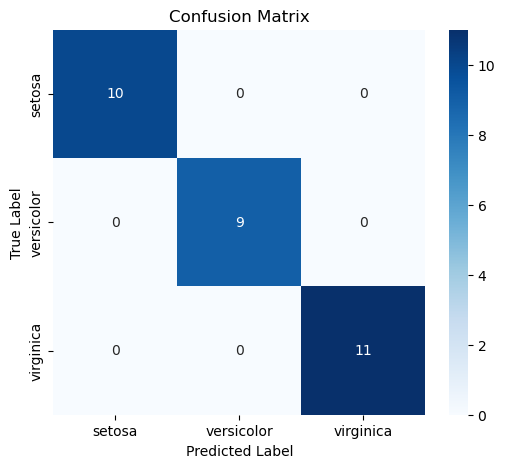

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Real-World Project: Customer Churn Prediction using Bagging Classifier
We'll apply the Bagging Classifier to a real-world problem: predicting customer churn in a telecom company. The goal is to classify whether a customer will stay or leave based on their usage patterns and demographic details.

Step 1: Load and Explore the Dataset
We will use the Telco Customer Churn Dataset, which contains customer demographics, account details, and service usage.

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


In [19]:
# Load dataset (downloaded as CSV)
df = pd.read_csv("https://raw.githubusercontent.com/dsrscientist/DSData/master/Telecom_customer_churn.csv")

# Display first few rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
print(df.isnull().sum())  # Check for missing values


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [21]:
# Convert categorical columns to numeric using Label Encoding
label_encoder = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoder[col] = le # store encoders for future use

In [22]:
# Select features and target
X = df.drop(columns=['Churn'])  # Features
y = df['Churn']  # Target variable

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
#  Initialize and Train the Bagging Classifier
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=20)
bagging_clf.fit(X_train.values, y_train.values)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=20)

In [28]:
y_pred = bagging_clf.predict(X_test.values)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.80
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



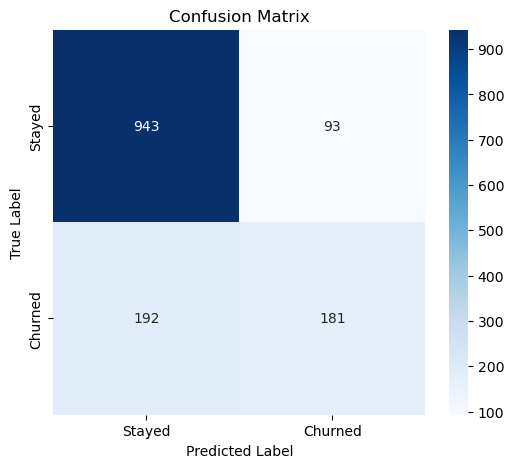

In [30]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(y_test, y_pred)

             Feature  Importance
15          Contract    0.165109
18    MonthlyCharges    0.163043
0         customerID    0.156435
19      TotalCharges    0.142076
5             tenure    0.117393
9     OnlineSecurity    0.041558
17     PaymentMethod    0.037523
16  PaperlessBilling    0.018319
1             gender    0.017467
3            Partner    0.016401


C:\Users\franc\AppData\Local\Temp\ipykernel_15032\3473168898.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df["Importance"], y=feature_importance_df["Feature"], palette="Blues_r")


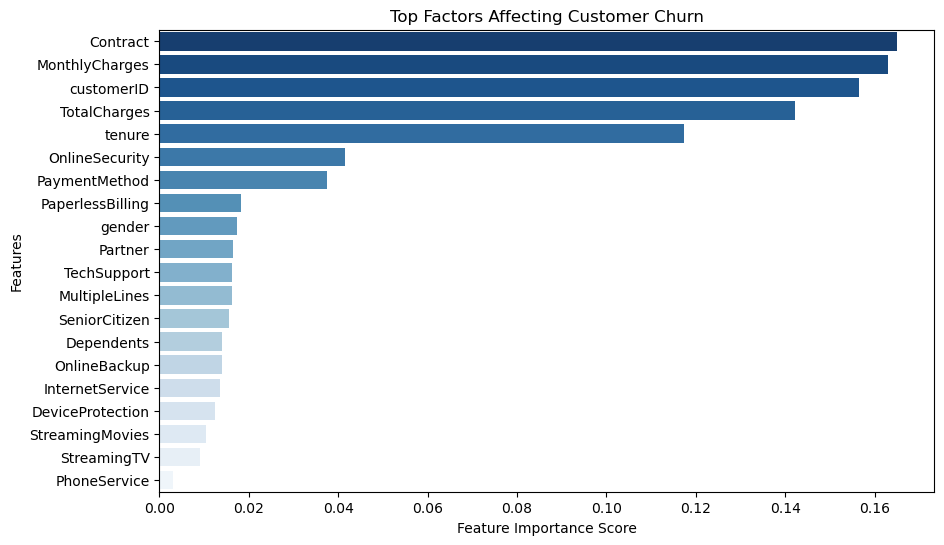

In [32]:
# Feature importance
# Extract feature importances from one of the trained base estimators
feature_importances = np.mean([tree.feature_importances_ for tree in bagging_clf.estimators_], axis=0)

# Convert to DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

# Display the top features
print(feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df["Importance"], y=feature_importance_df["Feature"], palette="Blues_r")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top Factors Affecting Customer Churn")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "n_estimators": [10, 20, 50],
    "max_samples": [0.5, 0.7, 1.0],
}


# Initialize GridSearch
grid_search = GridSearchCV(BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42),
                           param_grid, cv=5, scoring="accuracy", n_jobs=-1)

# Train models with different hyperparameters
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid_search.best_params_)



Best Parameters: {'max_samples': 0.5, 'n_estimators': 50}


In [40]:
best_est = grid_search.best_estimator_
best_est

y_pred = best_est.predict(X_test)

Accuracy: 0.80
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



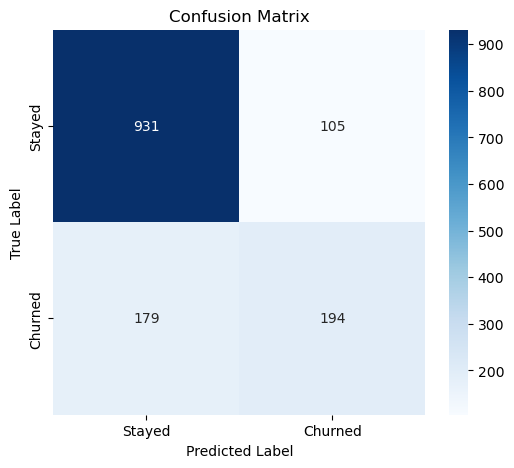

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


def plot_confusion_matrix(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(y_test, y_pred)

In [48]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
models = {
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, max_samples=0.5, max_features=8,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")


Bagging Accuracy: 0.80
Random Forest Accuracy: 0.80
Gradient Boosting Accuracy: 0.81
